# HW08-09: PyTorch MLP – регуляризация и оптимизация обучения

**Датасет:** EMNIST(split="balanced") (Вариант B)
**Цель:** Исследовать влияние регуляризации (Dropout, BatchNorm, EarlyStopping) и параметров оптимизации (LR, оптимизаторы, weight decay) на качество обучения MLP.

## 2.3.1. Импорты, seed и устройство

In [13]:
# Импорты (раздел 2.3.1)
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

# Проверка версий
print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

# Функция для фиксации seed (раздел 2.3.1)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Установка seed
SEED = 42
set_seed(SEED)

# Выбор устройства (раздел 2.3.1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Создание папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
device: cpu


## 2.3.2. Данные и DataLoader

Загружаем датасет EMNIST (split="balanced") через torchvision, создаём разбиение train/val/test.
Выполняем sanity-check батчей.

In [14]:
# Трансформации (раздел 2.3.2)
# EMNIST - grayscale изображения 28x28, как и MNIST/KMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # нормализация [0,1] -> [-1,1]
])

# Загрузка датасета (раздел 2.3.2)
train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

print(f"train size: {len(train_full)}")
print(f"test size: {len(test_ds)}")
print(f"number of classes: {len(train_full.classes)}")

# Разбиение train/val (80/20) с фиксированным seed (раздел 2.3.2)
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=generator)

print(f"\ntrain split: {len(train_ds)}")
print(f"val split: {len(val_ds)}")

# DataLoader (раздел 2.3.2)
# Для Windows num_workers=0 во избежание ошибок multiprocessing
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Sanity-check (раздел 2.3.2)
x_batch, y_batch = next(iter(train_loader))
print(f"\nBatch check:")
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")
print(f"x range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

train size: 112800
test size: 18800
number of classes: 47

train split: 90240
val split: 22560

Batch check:
x_batch: torch.Size([64, 1, 28, 28]), torch.float32
y_batch: torch.Size([64]), torch.int64
x range: [-1.000, 1.000]


## 2.3.3. Модель MLP и цикл обучения

Реализуем MLP как `nn.Module`, функции обучения и валидации.
Для EMNIST balanced количество классов = 47.

In [15]:
# Модель MLP (раздел 2.3.3)
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,  # EMNIST balanced has 47 classes
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check модели (раздел 2.3.3)
# Используем переменные из предыдущего блока (x_batch)
model_check = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out_check = model_check(x_batch.to(device))
print(f"Model output shape: {out_check.shape}")
print(f"Expected classes: {len(train_full.classes)}")

Model output shape: torch.Size([64, 47])
Expected classes: 47


In [16]:
# Вспомогательные функции (раздел 2.3.3)
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Цикл обучения (раздел 2.3.3)
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

# EarlyStopping (раздел 3.1 E4)
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# Функция fit (раздел 2.3.3)
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} |  "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} |  "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f} "
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}.  "
                        f"Лучший val_acc={early_stopping.best_score:.4f} "
                    )
                early_stopping.restore_best(model)
                break

    return history

## 3.1. Часть A (S08): регуляризация (E1-E4)

Проводим 4 эксперимента для исследования влияния регуляризации:
- **E1 (Base):** Базовая модель без регуляризации.
- **E2 (Dropout):** Добавляем Dropout.
- **E3 (BatchNorm):** Добавляем BatchNorm.
- **E4 (EarlyStopping):** Лучшая из (E2/E3) + EarlyStopping.

Результаты сохраняем для отчёта и артефактов.

In [17]:
# Подготовка к экспериментам (Раздел 3.1)
import pandas as pd
from datetime import datetime

# Список для сбора результатов (потом сохраним в runs.csv)
experiments_log = []

def run_experiment(exp_id, model_config, train_config, early_stopping=None):
    """
    Универсальная функция запуска эксперимента.
    """
    print(f"\n--- Запуск эксперимента {exp_id} ---")

    # Сброс seed для воспроизводимости каждого эксперимента
    set_seed(SEED)

    # Инициализация модели
    model = MLP(
        input_dim=28*28,
        num_classes=47,  # EMNIST balanced
        **model_config
    ).to(device)

    # Оптимизатор и Loss
    optimizer = train_config['optimizer'](model.parameters(), lr=train_config['lr'])
    criterion = nn.CrossEntropyLoss()

    # Обучение
    history = fit(
        model, train_loader, val_loader,
        optimizer, criterion, device,
        epochs=train_config['epochs'],
        early_stopping=early_stopping,
        verbose=True
    )

    # Фиксация лучших метрик на валидации
    best_val_acc = max(history['val_acc'])
    best_val_loss = min(history['val_loss'])
    epochs_trained = len(history['val_acc'])

    # Запись в лог
    log_entry = {
        'experiment_id': exp_id,
        'dataset': 'EMNIST_balanced',
        'seed': SEED,
        'model_summary': str(model_config),
        'optimizer': train_config['optimizer'].__name__,
        'lr': train_config['lr'],
        'momentum': train_config.get('momentum', 0),
        'weight_decay': train_config.get('weight_decay', 0),
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss
    }
    experiments_log.append(log_entry)

    print(f"Experiment {exp_id} finished. Best Val Acc: {best_val_acc:.4f}")

    return model, history, log_entry

# Проверка папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

### Эксперимент E1: Baseline

Базовая конфигурация:
- Hidden dims: (256, 128)
- Activation: ReLU
- Dropout: 0.0
- BatchNorm: False
- Optimizer: Adam (lr=1e-3)
- Epochs: 20


--- Запуск эксперимента E1 ---
epoch 01/20 |  train loss=1.1848, acc=0.6528 |  val loss=0.8082, acc=0.7438 
epoch 02/20 |  train loss=0.6804, acc=0.7817 |  val loss=0.6419, acc=0.7935 
epoch 03/20 |  train loss=0.5767, acc=0.8099 |  val loss=0.5896, acc=0.8015 
epoch 04/20 |  train loss=0.5191, acc=0.8245 |  val loss=0.5544, acc=0.8176 
epoch 05/20 |  train loss=0.4808, acc=0.8349 |  val loss=0.5211, acc=0.8273 
epoch 06/20 |  train loss=0.4515, acc=0.8429 |  val loss=0.5265, acc=0.8286 
epoch 07/20 |  train loss=0.4332, acc=0.8478 |  val loss=0.5216, acc=0.8274 
epoch 08/20 |  train loss=0.4094, acc=0.8539 |  val loss=0.5220, acc=0.8315 
epoch 09/20 |  train loss=0.3920, acc=0.8577 |  val loss=0.5268, acc=0.8350 
epoch 10/20 |  train loss=0.3813, acc=0.8613 |  val loss=0.5386, acc=0.8306 
epoch 11/20 |  train loss=0.3690, acc=0.8652 |  val loss=0.5180, acc=0.8369 
epoch 12/20 |  train loss=0.3576, acc=0.8685 |  val loss=0.5512, acc=0.8270 
epoch 13/20 |  train loss=0.3441, acc=0.8720

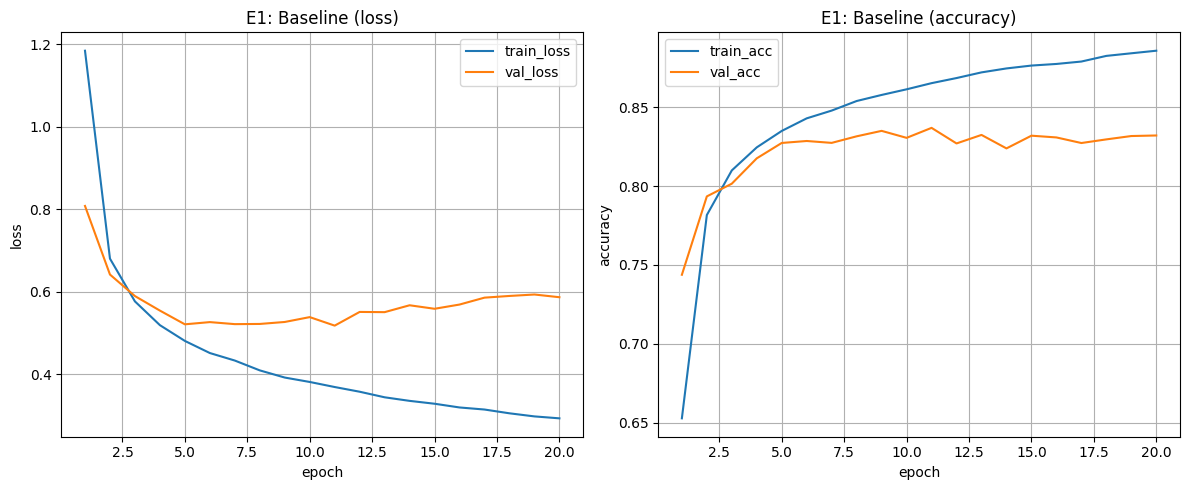

In [18]:
# Эксперимент E1 (Раздел 3.1)
model_config_e1 = {
    'hidden_dims': (256, 128),
    'activation': 'relu',
    'dropout_p': 0.0,
    'use_batchnorm': False
}

train_config_e1 = {
    'optimizer': optim.Adam,
    'lr': 1e-3,
    'epochs': 20
}

model_e1, history_e1, log_e1 = run_experiment('E1', model_config_e1, train_config_e1)
plot_history(history_e1, title="E1: Baseline")

### Эксперимент E2: Dropout

Добавляем регуляризацию Dropout для борьбы с переобучением:
- Dropout p: 0.3
- Остальные параметры как в E1.


--- Запуск эксперимента E2 ---
epoch 01/20 |  train loss=1.5678, acc=0.5446 |  val loss=0.8845, acc=0.7284 
epoch 02/20 |  train loss=1.0594, acc=0.6745 |  val loss=0.7321, acc=0.7686 
epoch 03/20 |  train loss=0.9494, acc=0.7019 |  val loss=0.6742, acc=0.7798 
epoch 04/20 |  train loss=0.8914, acc=0.7176 |  val loss=0.6401, acc=0.7906 
epoch 05/20 |  train loss=0.8584, acc=0.7274 |  val loss=0.6213, acc=0.7954 
epoch 06/20 |  train loss=0.8331, acc=0.7332 |  val loss=0.5994, acc=0.8048 
epoch 07/20 |  train loss=0.8202, acc=0.7360 |  val loss=0.6052, acc=0.8014 
epoch 08/20 |  train loss=0.8066, acc=0.7399 |  val loss=0.5839, acc=0.8061 
epoch 09/20 |  train loss=0.7924, acc=0.7432 |  val loss=0.5882, acc=0.8098 
epoch 10/20 |  train loss=0.7866, acc=0.7450 |  val loss=0.5723, acc=0.8098 
epoch 11/20 |  train loss=0.7741, acc=0.7492 |  val loss=0.5589, acc=0.8165 
epoch 12/20 |  train loss=0.7684, acc=0.7513 |  val loss=0.5567, acc=0.8150 
epoch 13/20 |  train loss=0.7609, acc=0.7531

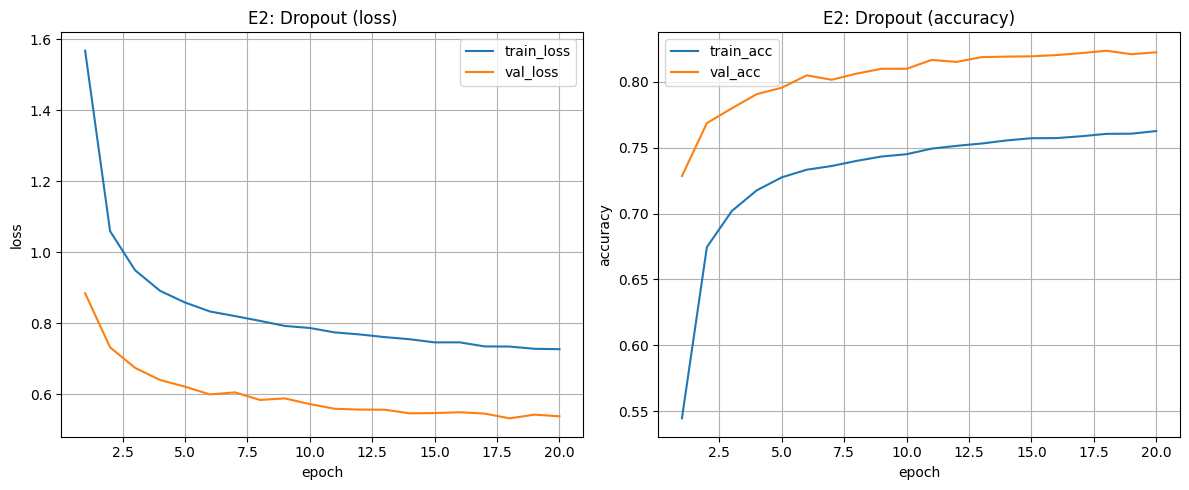

In [19]:
# Эксперимент E2 (Раздел 3.1)
model_config_e2 = {
    'hidden_dims': (256, 128),
    'activation': 'relu',
    'dropout_p': 0.3,
    'use_batchnorm': False
}

train_config_e2 = {
    'optimizer': optim.Adam,
    'lr': 1e-3,
    'epochs': 20
}

model_e2, history_e2, log_e2 = run_experiment('E2', model_config_e2, train_config_e2)
plot_history(history_e2, title="E2: Dropout")

### Эксперимент E3: BatchNorm

Добавляем нормализацию активаций для стабильности обучения:
- BatchNorm: True
- Dropout: 0.0 (обычно не используют вместе в простых MLP без тщательной настройки)
- Остальные параметры как в E1.


--- Запуск эксперимента E3 ---
epoch 01/20 |  train loss=0.9262, acc=0.7329 |  val loss=0.5826, acc=0.8072 
epoch 02/20 |  train loss=0.5379, acc=0.8207 |  val loss=0.5046, acc=0.8327 
epoch 03/20 |  train loss=0.4666, acc=0.8388 |  val loss=0.4893, acc=0.8342 
epoch 04/20 |  train loss=0.4219, acc=0.8510 |  val loss=0.4603, acc=0.8448 
epoch 05/20 |  train loss=0.3919, acc=0.8592 |  val loss=0.4577, acc=0.8446 
epoch 06/20 |  train loss=0.3656, acc=0.8663 |  val loss=0.4566, acc=0.8452 
epoch 07/20 |  train loss=0.3476, acc=0.8730 |  val loss=0.4609, acc=0.8467 
epoch 08/20 |  train loss=0.3292, acc=0.8778 |  val loss=0.4609, acc=0.8489 
epoch 09/20 |  train loss=0.3128, acc=0.8820 |  val loss=0.4614, acc=0.8510 
epoch 10/20 |  train loss=0.2977, acc=0.8857 |  val loss=0.4629, acc=0.8493 
epoch 11/20 |  train loss=0.2867, acc=0.8902 |  val loss=0.4663, acc=0.8527 
epoch 12/20 |  train loss=0.2769, acc=0.8922 |  val loss=0.4766, acc=0.8467 
epoch 13/20 |  train loss=0.2672, acc=0.8948

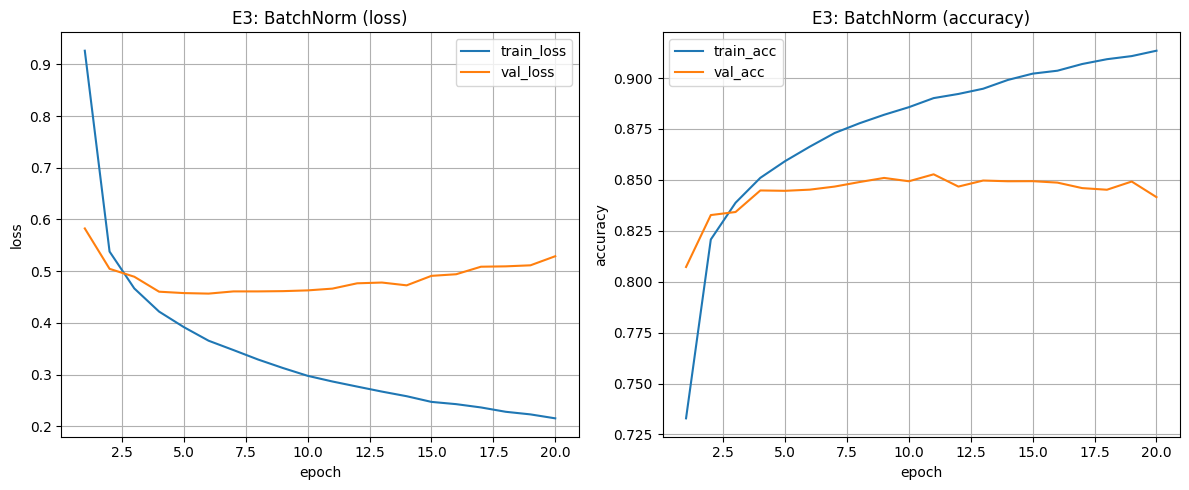

In [20]:
# Эксперимент E3 (Раздел 3.1)
model_config_e3 = {
    'hidden_dims': (256, 128),
    'activation': 'relu',
    'dropout_p': 0.0,
    'use_batchnorm': True
}

train_config_e3 = {
    'optimizer': optim.Adam,
    'lr': 1e-3,
    'epochs': 20
}

model_e3, history_e3, log_e3 = run_experiment('E3', model_config_e3, train_config_e3)
plot_history(history_e3, title="E3: BatchNorm")

### Эксперимент E4: EarlyStopping

Выбираем лучшую архитектуру из E2/E3 по `val_accuracy` и добавляем раннюю остановку.
- Patience: 5
- Max Epochs: 50 (чтобы EarlyStopping мог сработать)
- Сохраняем модель и конфиг как лучшие артефакты.

E3 (BatchNorm) показал лучший результат, используем его архитектуру для E4.

--- Запуск эксперимента E4 ---
epoch 01/50 |  train loss=0.9262, acc=0.7329 |  val loss=0.5826, acc=0.8072 
epoch 02/50 |  train loss=0.5379, acc=0.8207 |  val loss=0.5046, acc=0.8327 
epoch 03/50 |  train loss=0.4666, acc=0.8388 |  val loss=0.4893, acc=0.8342 
epoch 04/50 |  train loss=0.4219, acc=0.8510 |  val loss=0.4603, acc=0.8448 
epoch 05/50 |  train loss=0.3919, acc=0.8592 |  val loss=0.4577, acc=0.8446 
epoch 06/50 |  train loss=0.3656, acc=0.8663 |  val loss=0.4566, acc=0.8452 
epoch 07/50 |  train loss=0.3476, acc=0.8730 |  val loss=0.4609, acc=0.8467 
epoch 08/50 |  train loss=0.3292, acc=0.8778 |  val loss=0.4609, acc=0.8489 
epoch 09/50 |  train loss=0.3128, acc=0.8820 |  val loss=0.4614, acc=0.8510 
epoch 10/50 |  train loss=0.2977, acc=0.8857 |  val loss=0.4629, acc=0.8493 
epoch 11/50 |  train loss=0.2867, acc=0.8902 |  val loss=0.4663, acc=0.8527 
epoch 12/50 |  train loss=0.2769, acc=0.8922 

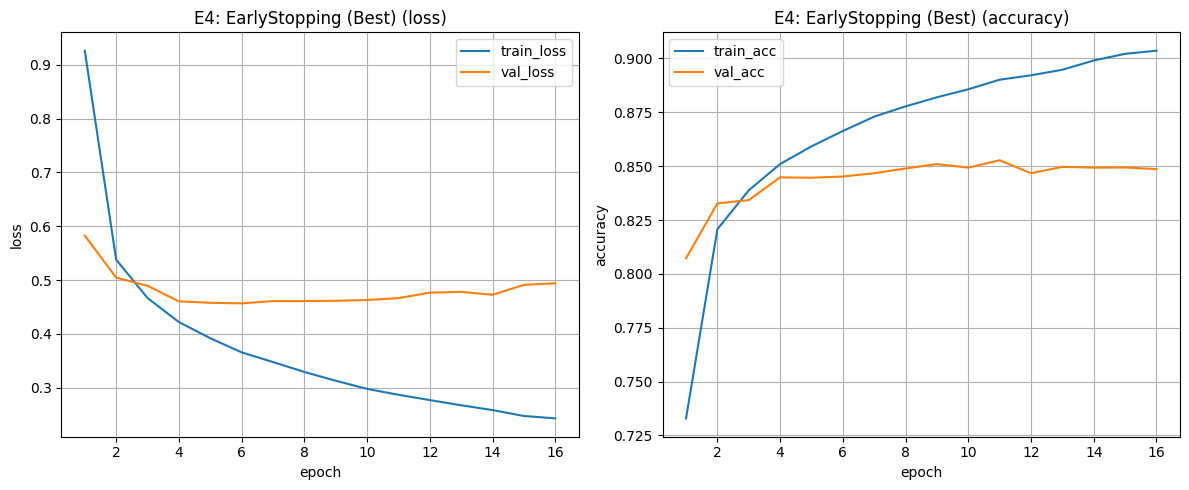


--- Сохранение артефактов ---
Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json


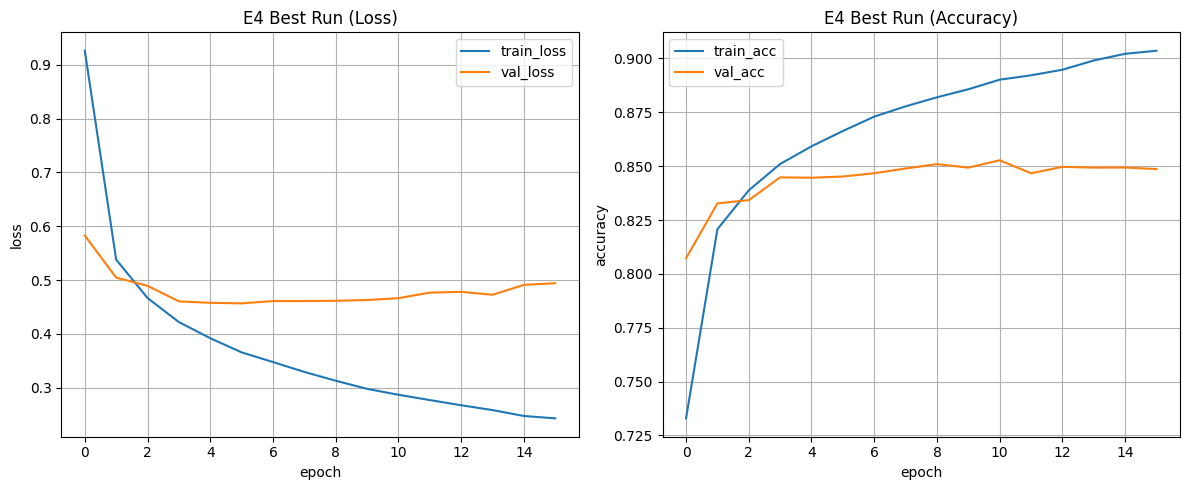

Saved: artifacts/figures/curves_best.png

Final Test Accuracy (Best Model E4): 0.8486


In [21]:
# Эксперимент E4 (Раздел 3.1)
# Выбираем лучшую конфигурацию из E2/E3
if log_e2['best_val_accuracy'] > log_e3['best_val_accuracy']:
    best_config_prev = model_config_e2
    print("E2 (Dropout) показал лучший результат, используем его архитектуру для E4.")
else:
    best_config_prev = model_config_e3
    print("E3 (BatchNorm) показал лучший результат, используем его архитектуру для E4.")

# Конфигурация E4
model_config_e4 = best_config_prev.copy()
train_config_e4 = {
    'optimizer': optim.Adam,
    'lr': 1e-3,
    'epochs': 50  # Увеличиваем число эпох для EarlyStopping
}

# EarlyStopping
early_stopping_e4 = EarlyStopping(patience=5, min_delta=0.001)

model_e4, history_e4, log_e4 = run_experiment('E4', model_config_e4, train_config_e4, early_stopping=early_stopping_e4)
plot_history(history_e4, title="E4: EarlyStopping (Best)")

# --- Сохранение артефактов (Раздел 4) ---
print("\n--- Сохранение артефактов ---")

# 1. Лучшая модель (state_dict)
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print("Saved: artifacts/best_model.pt")

# 2. Конфиг лучшей модели
best_config = {
    'dataset': 'EMNIST_balanced',
    'seed': SEED,
    'model_config': model_config_e4,
    'train_config': {
        'optimizer': 'Adam',
        'lr': train_config_e4['lr'],
        'epochs_limit': train_config_e4['epochs'],
        'early_stopping_patience': 5
    },
    'metrics': {
        'best_val_accuracy': log_e4['best_val_accuracy'],
        'best_val_loss': log_e4['best_val_loss']
    }
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print("Saved: artifacts/best_config.json")

# 3. График лучшего прогона
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], label='train_loss')
plt.plot(history_e4['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('E4 Best Run (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], label='train_acc')
plt.plot(history_e4['val_acc'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('E4 Best Run (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()
print("Saved: artifacts/figures/curves_best.png")

# 4. Финальная оценка на Test (только для лучшей модели!)
test_loss, test_acc = evaluate(model_e4, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nFinal Test Accuracy (Best Model E4): {test_acc:.4f}")
log_e4['test_accuracy'] = test_acc

## 3.2. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

Проводим 3 эксперимента для диагностики learning rate и сравнения оптимизаторов:
- **O1 (LR большой):** Adam, lr=1e-1 – покажет нестабильность обучения.
- **O2 (LR маленький):** Adam, lr=1e-5 – покажет очень медленную сходимость.
- **O3 (SGD+momentum+WD):** SGD с momentum=0.9, weight_decay=1e-4 – сравнение с Adam.

Архитектура модели фиксируется как в E4 (лучшая из части A).


--- Запуск эксперимента O1 (LR слишком большой) ---
epoch 01/8 |  train loss=1.9644, acc=0.4254 |  val loss=1.1072, acc=0.6386 
epoch 02/8 |  train loss=1.6484, acc=0.5035 |  val loss=0.9770, acc=0.6851 
epoch 03/8 |  train loss=1.5676, acc=0.5193 |  val loss=0.9482, acc=0.6813 
epoch 04/8 |  train loss=1.5327, acc=0.5333 |  val loss=0.8967, acc=0.7024 
epoch 05/8 |  train loss=1.4898, acc=0.5437 |  val loss=0.8939, acc=0.7139 
epoch 06/8 |  train loss=1.4555, acc=0.5527 |  val loss=0.8244, acc=0.7332 
epoch 07/8 |  train loss=1.4725, acc=0.5500 |  val loss=0.8407, acc=0.7249 
epoch 08/8 |  train loss=1.4440, acc=0.5549 |  val loss=0.8420, acc=0.7288 


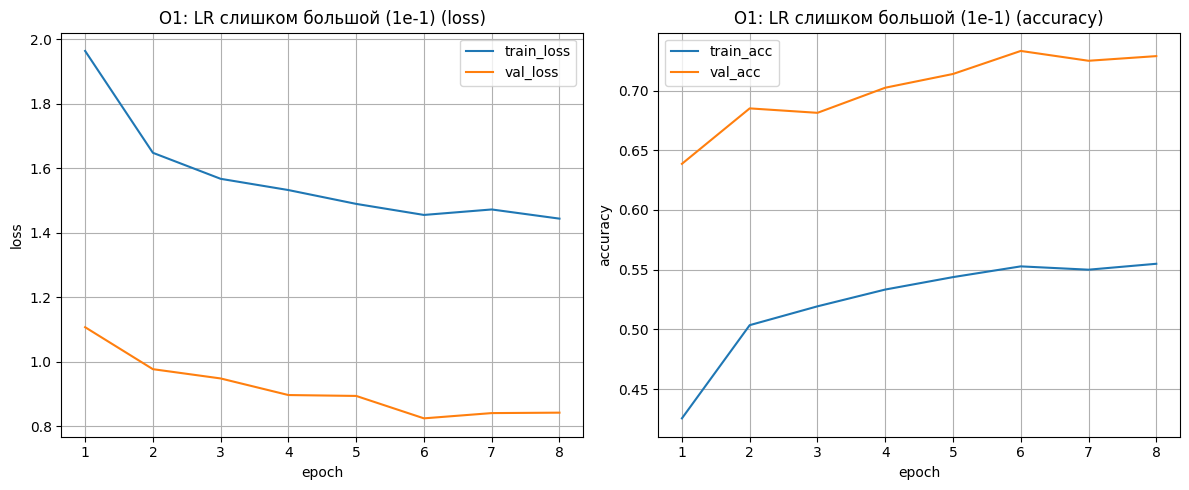

In [22]:
# Эксперимент O1 (Раздел 3.2)
print("\n--- Запуск эксперимента O1 (LR слишком большой) ---")

set_seed(SEED)
model_o1 = MLP(
    hidden_dims=(256, 128),
    activation='relu',
    dropout_p=0.3,
    use_batchnorm=True,
    num_classes=47
).to(device)

train_config_o1 = {
    'optimizer': optim.Adam,
    'lr': 1e-1,  # Слишком большой LR
    'epochs': 8,
    'momentum': 0,
    'weight_decay': 0
}

criterion = nn.CrossEntropyLoss()
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=train_config_o1['lr'])

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=train_config_o1['epochs'],
    early_stopping=None,
    verbose=True
)

log_o1 = {
    'experiment_id': 'O1',
    'dataset': 'EMNIST_balanced',
    'seed': SEED,
    'model_summary': str({'hidden_dims': (256, 128), 'dropout_p': 0.3, 'use_batchnorm': True}),
    'optimizer': 'Adam',
    'lr': train_config_o1['lr'],
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_o1['val_acc']),
    'best_val_accuracy': max(history_o1['val_acc']),
    'best_val_loss': min(history_o1['val_loss'])
}
experiments_log.append(log_o1)

plot_history(history_o1, title="O1: LR слишком большой (1e-1)")


--- Запуск эксперимента O2 (LR слишком маленький) ---
epoch 01/8 |  train loss=3.5907, acc=0.1093 |  val loss=3.2105, acc=0.3194 
epoch 02/8 |  train loss=3.1017, acc=0.2808 |  val loss=2.8407, acc=0.4513 
epoch 03/8 |  train loss=2.7992, acc=0.3825 |  val loss=2.5662, acc=0.5179 
epoch 04/8 |  train loss=2.5616, acc=0.4448 |  val loss=2.3357, acc=0.5618 
epoch 05/8 |  train loss=2.3569, acc=0.4878 |  val loss=2.1367, acc=0.5935 
epoch 06/8 |  train loss=2.1883, acc=0.5195 |  val loss=1.9506, acc=0.6145 
epoch 07/8 |  train loss=2.0402, acc=0.5440 |  val loss=1.8254, acc=0.6335 
epoch 08/8 |  train loss=1.9148, acc=0.5620 |  val loss=1.6889, acc=0.6473 


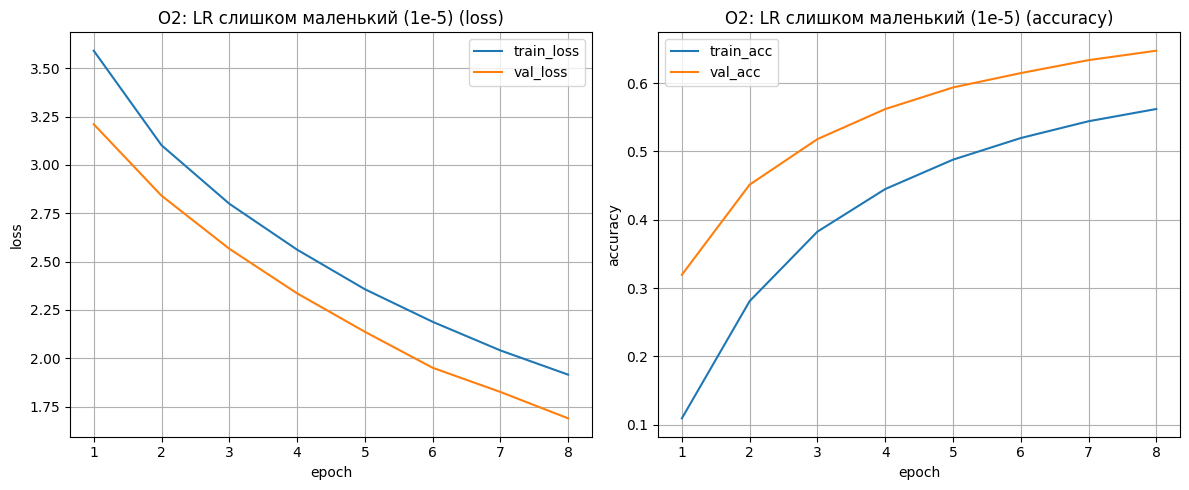

In [23]:
# Эксперимент O2 (Раздел 3.2)
print("\n--- Запуск эксперимента O2 (LR слишком маленький) ---")

set_seed(SEED)
model_o2 = MLP(
    hidden_dims=(256, 128),
    activation='relu',
    dropout_p=0.3,
    use_batchnorm=True,
    num_classes=47
).to(device)

train_config_o2 = {
    'optimizer': optim.Adam,
    'lr': 1e-5,  # Слишком маленький LR
    'epochs': 8,
    'momentum': 0,
    'weight_decay': 0
}

criterion = nn.CrossEntropyLoss()
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=train_config_o2['lr'])

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=train_config_o2['epochs'],
    early_stopping=None,
    verbose=True
)

log_o2 = {
    'experiment_id': 'O2',
    'dataset': 'EMNIST_balanced',
    'seed': SEED,
    'model_summary': str({'hidden_dims': (256, 128), 'dropout_p': 0.3, 'use_batchnorm': True}),
    'optimizer': 'Adam',
    'lr': train_config_o2['lr'],
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_o2['val_acc']),
    'best_val_accuracy': max(history_o2['val_acc']),
    'best_val_loss': min(history_o2['val_loss'])
}
experiments_log.append(log_o2)

plot_history(history_o2, title="O2: LR слишком маленький (1e-5)")


--- Запуск эксперимента O3 (SGD+momentum+weight_decay) ---
epoch 01/15 |  train loss=1.3690, acc=0.6064 |  val loss=0.7234, acc=0.7763 
epoch 02/15 |  train loss=0.9285, acc=0.7096 |  val loss=0.6179, acc=0.8032 
epoch 03/15 |  train loss=0.8230, acc=0.7363 |  val loss=0.5727, acc=0.8095 
epoch 04/15 |  train loss=0.7694, acc=0.7516 |  val loss=0.5393, acc=0.8192 
epoch 05/15 |  train loss=0.7245, acc=0.7663 |  val loss=0.5157, acc=0.8276 
epoch 06/15 |  train loss=0.7042, acc=0.7691 |  val loss=0.5050, acc=0.8336 
epoch 07/15 |  train loss=0.6782, acc=0.7760 |  val loss=0.4917, acc=0.8351 
epoch 08/15 |  train loss=0.6631, acc=0.7822 |  val loss=0.4829, acc=0.8378 
epoch 09/15 |  train loss=0.6465, acc=0.7857 |  val loss=0.4795, acc=0.8397 
epoch 10/15 |  train loss=0.6360, acc=0.7899 |  val loss=0.4699, acc=0.8410 
epoch 11/15 |  train loss=0.6263, acc=0.7914 |  val loss=0.4627, acc=0.8455 
epoch 12/15 |  train loss=0.6139, acc=0.7955 |  val loss=0.4621, acc=0.8426 
epoch 13/15 |  t

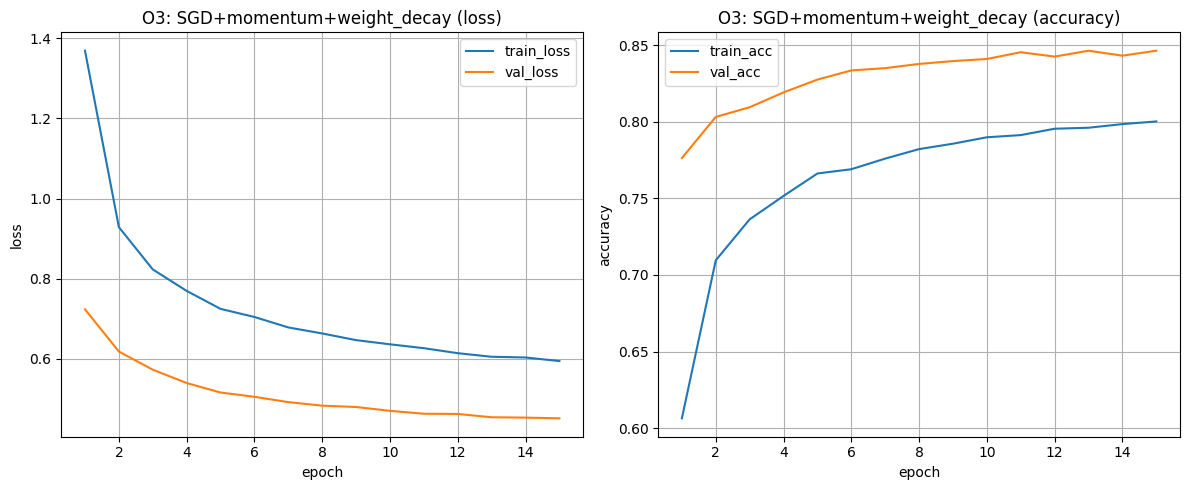

In [24]:
# Эксперимент O3 (Раздел 3.2)
print("\n--- Запуск эксперимента O3 (SGD+momentum+weight_decay) ---")

set_seed(SEED)
model_o3 = MLP(
    hidden_dims=(256, 128),
    activation='relu',
    dropout_p=0.3,
    use_batchnorm=True,
    num_classes=47
).to(device)

train_config_o3 = {
    'optimizer': optim.SGD,
    'lr': 1e-2,
    'epochs': 15,
    'momentum': 0.9,
    'weight_decay': 1e-4
}

criterion = nn.CrossEntropyLoss()
optimizer_o3 = optim.SGD(
    model_o3.parameters(),
    lr=train_config_o3['lr'],
    momentum=train_config_o3['momentum'],
    weight_decay=train_config_o3['weight_decay']
)

history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=train_config_o3['epochs'],
    early_stopping=None,
    verbose=True
)

log_o3 = {
    'experiment_id': 'O3',
    'dataset': 'EMNIST_balanced',
    'seed': SEED,
    'model_summary': str({'hidden_dims': (256, 128), 'dropout_p': 0.3, 'use_batchnorm': True}),
    'optimizer': 'SGD',
    'lr': train_config_o3['lr'],
    'momentum': train_config_o3['momentum'],
    'weight_decay': train_config_o3['weight_decay'],
    'epochs_trained': len(history_o3['val_acc']),
    'best_val_accuracy': max(history_o3['val_acc']),
    'best_val_loss': min(history_o3['val_loss'])
}
experiments_log.append(log_o3)

plot_history(history_o3, title="O3: SGD+momentum+weight_decay")

## 4. Артефакты эксперимента

Сохраняем все результаты в папку `artifacts/`:
- `runs.csv` – таблица всех экспериментов
- `best_model.pt` – веса лучшей модели (E4)
- `best_config.json` – конфиг лучшей модели
- `figures/curves_best.png` – кривые обучения лучшего прогона
- `figures/curves_lr_extremes.png` – кривые O1 и O2


--- Сохранение артефактов ---
Saved: artifacts/runs.csv
Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json


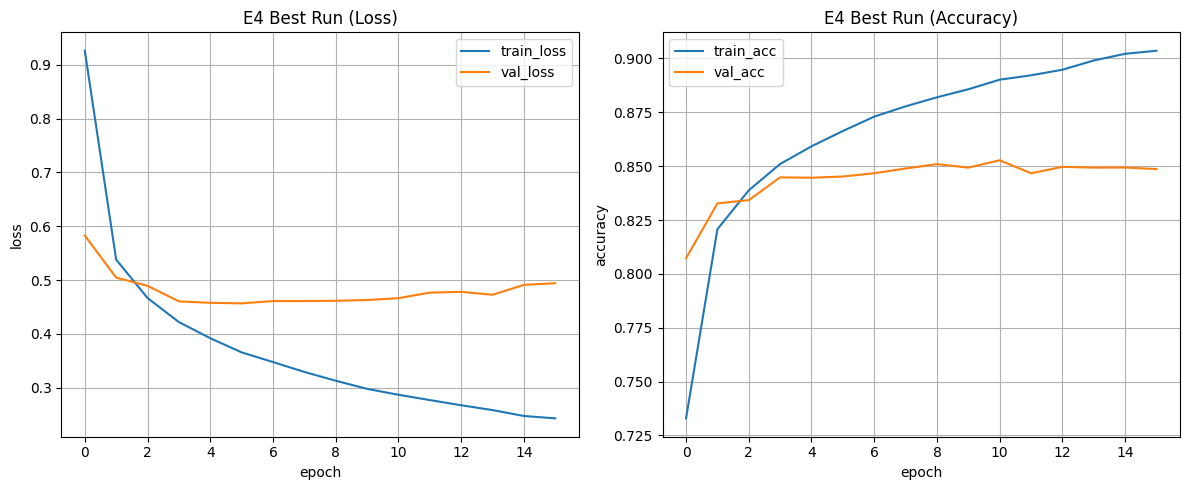

Saved: artifacts/figures/curves_best.png


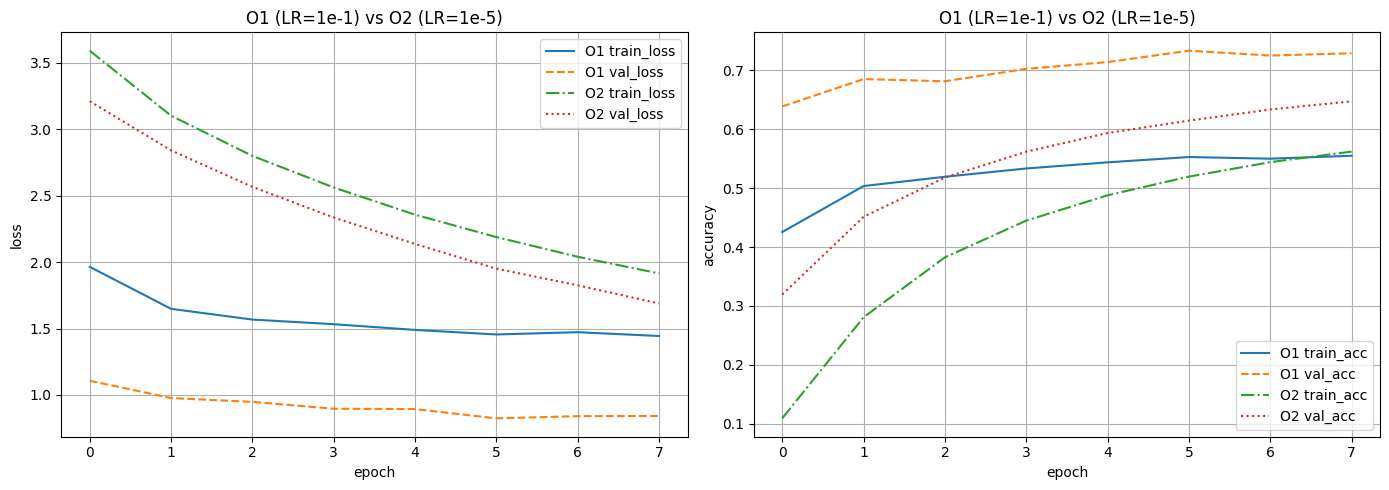

Saved: artifacts/figures/curves_lr_extremes.png

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
experiment_id optimizer      lr  best_val_accuracy  epochs_trained
           E1      Adam 0.00100           0.836889              20
           E2      Adam 0.00100           0.823477              20
           E3      Adam 0.00100           0.852735              20
           E4      Adam 0.00100           0.852735              16
           O1      Adam 0.10000           0.733180               8
           O2      Adam 0.00001           0.647265               8
           O3       SGD 0.01000           0.846450              15


In [25]:
# Сохранение артефактов (Раздел 4)
import pandas as pd
import json
import os

print("\n--- Сохранение артефактов ---")

# Создаём папки
os.makedirs("artifacts/figures", exist_ok=True)

# 1. Сохраняем runs.csv
runs_df = pd.DataFrame(experiments_log)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Saved: artifacts/runs.csv")

# 2. Сохраняем best_model.pt (из E4)
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print("Saved: artifacts/best_model.pt")

# 3. Сохраняем best_config.json
best_config = {
    'dataset': 'EMNIST_balanced',
    'seed': SEED,
    'model_config': {
        'input_dim': 28*28,
        'hidden_dims': (256, 128),
        'num_classes': 47,
        'activation': 'relu',
        'dropout_p': 0.3,
        'use_batchnorm': True
    },
    'train_config': {
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs_limit': 50,
        'early_stopping_patience': 5,
        'batch_size': BATCH_SIZE
    },
    'metrics': {
        'best_val_accuracy': log_e4['best_val_accuracy'],
        'best_val_loss': log_e4['best_val_loss'],
        'test_accuracy': test_acc
    }
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print("Saved: artifacts/best_config.json")

# 4. Сохраняем curves_best.png (E4)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], label='train_loss')
plt.plot(history_e4['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('E4 Best Run (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], label='train_acc')
plt.plot(history_e4['val_acc'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('E4 Best Run (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150)
plt.show()
print("Saved: artifacts/figures/curves_best.png")

# 5. Сохраняем curves_lr_extremes.png (O1 и O2)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_o1['train_loss'], label='O1 train_loss', linestyle='-')
plt.plot(history_o1['val_loss'], label='O1 val_loss', linestyle='--')
plt.plot(history_o2['train_loss'], label='O2 train_loss', linestyle='-.')
plt.plot(history_o2['val_loss'], label='O2 val_loss', linestyle=':')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('O1 (LR=1e-1) vs O2 (LR=1e-5)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1['train_acc'], label='O1 train_acc', linestyle='-')
plt.plot(history_o1['val_acc'], label='O1 val_acc', linestyle='--')
plt.plot(history_o2['train_acc'], label='O2 train_acc', linestyle='-.')
plt.plot(history_o2['val_acc'], label='O2 val_acc', linestyle=':')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('O1 (LR=1e-1) vs O2 (LR=1e-5)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()
print("Saved: artifacts/figures/curves_lr_extremes.png")

# 6. Финальная таблица результатов
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)
print(runs_df[['experiment_id', 'optimizer', 'lr', 'best_val_accuracy', 'epochs_trained']].to_string(index=False))